C:\Users\chaoy\AppData\Local\Temp\ipykernel_238812\3413269197.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(pr_df['precision'].values, pr_df['recall'].values)
C:\Users\chaoy\AppData\Local\Temp\ipykernel_238812\3413269197.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(pr_df['precision'].values, pr_df['recall'].values)
C:\Users\chaoy\AppData\Local\Temp\ipykernel_238812\3413269197.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(pr_df['precision'].values, pr_df['recall'].values)
C:\Users\chaoy\AppData\Local\Temp\ipykernel_238812\3413269197.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration

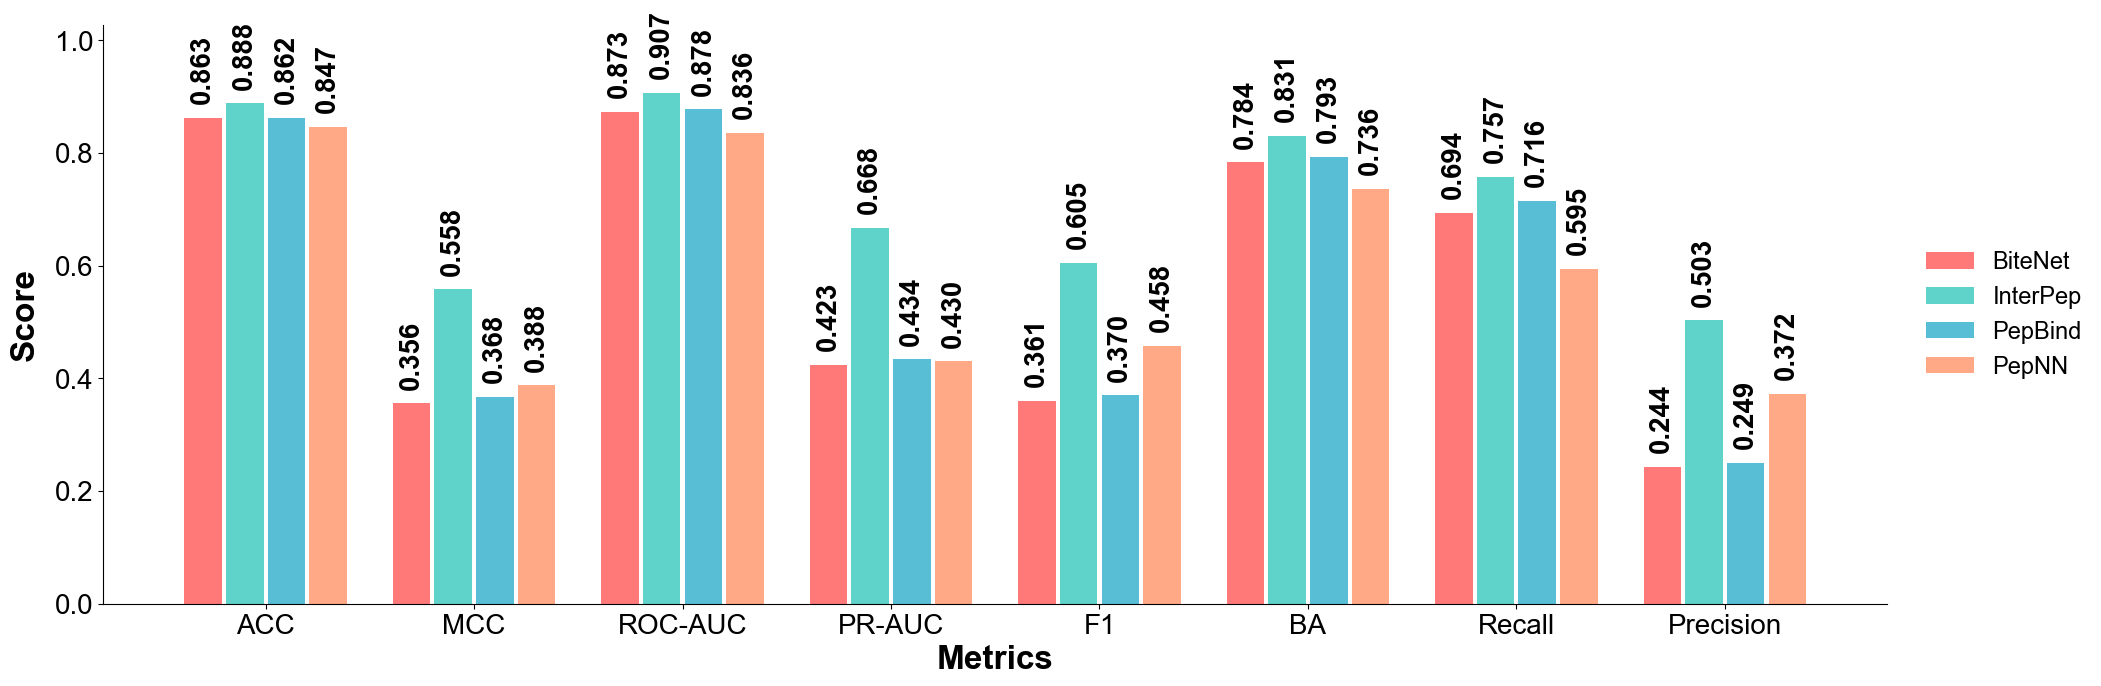

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

models = ['bitenet', 'interpep', 'pepbind', 'pepnn']
model_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
model_labels = ['BiteNet', 'InterPep', 'PepBind', 'PepNN']

data = {}
for model in models:
    metrics_df = pd.read_csv(f'{model}/test_metrics.csv')
    data[model] = metrics_df.iloc[0].to_dict()

    pr_curve_path = f'{model}/pr_curve.csv'
    if os.path.exists(pr_curve_path):
        pr_df = pd.read_csv(pr_curve_path)
        pr_df = pr_df.sort_values('recall')
        pr_auc = np.trapz(pr_df['precision'].values, pr_df['recall'].values)
        data[model]['test_pr_auc'] = pr_auc
    else:
        data[model]['test_pr_auc'] = np.nan

# 增加 PR AUC，Recall 与 Precision 仍排在最后
metrics = [
    'test_acc',
    'test_mcc',
    'test_auc',
    'test_pr_auc',
    'test_f1',
    'test_balanced_acc',
    'test_recall',
    'test_precision'
]
metric_labels = ['ACC', 'MCC', 'ROC-AUC', 'PR-AUC', 'F1', 'BA', 'Recall', 'Precision']

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(24, 7))

x = np.arange(len(metrics))
width = 0.18
spacing = 0.02
max_value = 0.0

for idx, model in enumerate(models):
    values = [data[model][metric] for metric in metrics]
    positions = x + (idx - 1.5) * (width + spacing)
    ax.bar(positions, values, width, color=model_colors[idx], alpha=0.9, edgecolor='none', label=model_labels[idx])
    max_value = max(max_value, max(values))
    for pos, val in zip(positions, values):
        ax.text(
            pos,
            val + 0.025,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            rotation=90,
            fontsize=20,
            fontweight='bold'
        )

ax.set_xlabel('Metrics', fontsize=24, fontweight='bold')
ax.set_ylabel('Score', fontsize=24, fontweight='bold', labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=20)

upper_ylim = min(1.10, max_value + 0.12)
ax.set_ylim(0, upper_ylim)
yticks = np.arange(0, upper_ylim + 0.001, 0.2)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=20)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=17)

plt.tight_layout(rect=[0, 0, 0.88, 1])
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/bar_plot1231.svg', format='svg', dpi=600, bbox_inches='tight')
plt.show()